# Prompt 1 

"The search engine in the notebook has a MAP@10 across all queries of 0.29. This is considered low. Please propose some updates to increase the score. For reference, large ecommerce websites have MAP@10 values between 0.6—0.8, although there is no expectation for your solution to be in that range. The strength of your ideas holds greater weight than the final MAP score of the solution."

# Promopt 3.1
"Please implement at least one change you suggest for prompt 1 to demonstrate an improvement in the MAP score. Please document your code changes with comments and markdown cells so we can follow your thought process".



### summary

| Model Type               | Speed     | MAP\@10  | Description / Best Use                                    |
| ------------------------ | --------- | -------- | --------------------------------------------------------- |
| **TF-IDF**               | Very Fast | 0.29     | Simple lexical baseline (name + description)               |
| **BM25**                 | Fast      | 0.34     | Stronger lexical match (no cleaning performs better here) |
| **SBERT**   | Moderate   | 0.36     | Semantic search with precomputed embeddings               |
| **BM25 + Cross-Encoder** | Slow      | **0.42** | **Best reranking accuracy** on top 50 candidates          |

**steps taken:** 

The initial retrieval (BM25) is strong enough to surface plausible candidates.

The cross-encoder is doing its job — applying nuanced pairwise scoring that bi-encoders and TF-IDF simply can't.

**why map@10 is hard to improve**

- label mismatch: I checked that the 'Exact' match has min of 1 product, 25% at 4 product, and 50% at 28 products, even with 28 matches, the top10 may not include all of them.
 
- my model may return great semantic matches (sentence BERT) that aren't labeled as 'Exact', and those own't get any MAP credits, that's why we could improve the map@k function to include partial matches

- according to my research, Wayfair (in WANDS) labels products as "Exact" only if they're identical or near-identical to the target product in a browsing session. It’s not recall-complete for all plausible matches. 

**why not hybrid scoring using BM25 + SBERT Fusion:**

this is worth trying, but can most likely improve the score by 0.1

**why ot Augment Text with Select Metadata: like the product features, product class, category hierarchy**

I checked the search query length in the query_df, the query itself is relatively very short, with mean and median at 3 words, and maximum at 10. My thoughts were that by improving the context in the product side alone, will have relatively minimal impact on the match result. 

**what's next**

I want to reach a higher MAP@K score (close to 0.6) taht would indicates on average, each query retrieves a significant number of truly relevant products (often labeled “Exact”) in the top 10 results, and does so with high ranking precision.

| Step                                            | Description | Est. MAP\@10 Gain |
| ----------------------------------------------- | ----------- | ----------------- |
| Better cross-encoder (e.g., MiniLM-L12-v2)      | +0.03–0.05  |                   |
| Rerank top 100+ instead of 50                   | +0.01–0.03  |                   |
| Fine-tune cross-encoder or bi-encoder           | +0.05–0.10  |                   |
| Hybrid candidate retrieval (BM25 + SBERT)       | +0.01–0.03  |                   |
| Structured filtering/boosting (category, brand) | +0.01–0.03  |                   |

**why I hesitate on trying LLM APIs**
- LLM isn't commonly used for (or at least not directly), but we could try LLM-backed rerankers like intfloat/e5-mistral-7b-instruct
- large number of queries can slow things down, not ideal on production envrionment,
- whereas Models like cross-encoder/ms-marco-MiniLM or deberta-v3 are purpose-built for dense pairwise ranking.

In [ ]:
# imports
import os
import json 
import pandas as pd
import numpy as np 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import nltk
from nltk.tokenize import word_tokenize
from sentence_transformers import CrossEncoder
import logging
import sys
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")

# load config file
def load_config(env='dev', config_file='config.json'):
    with open(config_file) as f:
        config = json.load(f)

    base_path = config.get(f"{env}_path")
    data_path = os.path.join(base_path, "data")
    model_path = os.path.join(base_path, "models")

    print("Base path:", base_path)    
    print("Data path:", data_path)
    print("Model path:", model_path)

    return base_path, data_path, model_path

# Logging Setup
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Retrieval")

# Download NLTK Resources
try:
    nltk.download('punkt', quiet=True)
except Exception as e:
    logger.warning(f"NLTK download failed: {e}")

# set up path and logging
ENV = 'dev'
base_path, data_path, model_path = load_config(ENV)

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


Base path: /Users/jillchow/HBS/hbs_search_engine
Data path: /Users/jillchow/HBS/hbs_search_engine/data
Model path: /Users/jillchow/HBS/hbs_search_engine/models


In [8]:
# utlity: 
# set up cross encoder
# load datasets
def load_cross_encoder(model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'):
    return CrossEncoder(model_name)

def load_datasets(data_path, sep='\t'):
    query_df = pd.read_csv(os.path.join(data_path, 'query.csv'), sep=sep)
    product_df = pd.read_csv(os.path.join(data_path, 'product.csv'), sep=sep)
    label_df = pd.read_csv(os.path.join(data_path, 'label.csv'), sep=sep)
    return query_df, product_df, label_df

In [ ]:
# Group BM25 + Cross-Encoder as a Retrieval Pipeline

from rank_bm25 import BM25Okapi

def build_bm25_index(product_df):
    corpus = (product_df['product_name'] + ' ' + product_df['product_description']).fillna("").astype(str).tolist()
    tokenized_corpus = [word_tokenize(doc.lower()) for doc in corpus]
    bm25 = BM25Okapi(tokenized_corpus)
    return bm25

def cross_encoder_pipeline(query, product_df, bm25, cross_encoder, top_n=50, top_k=10):
    tokenized_query = word_tokenize(query.lower())
    scores = bm25.get_scores(tokenized_query)
    candidate_indices = np.argsort(scores)[-top_n:][::-1]
    candidates = product_df.iloc[candidate_indices]

    candidate_texts = (
        candidates['product_name'] + ' ' +
        candidates['product_description']
    ).fillna('').tolist()
    
    query_pairs = [(query, text) for text in candidate_texts]
    rerank_scores = cross_encoder.predict(query_pairs, show_progress_bar=False)
    reranked_indices = np.argsort(rerank_scores)[::-1][:top_k]
    
    return product_df.iloc[[candidate_indices[i] for i in reranked_indices]]['product_id'].tolist()

# candidate_indices = [42, 500, 12, 777, 321, ..., 871]  
# reranked_indices = [2, 0, 4]  # top 3 after reranking BM25 candidates in 0-49

# # Final product rows we want are:
# [ candidate_indices[2], candidate_indices[0], candidate_indices[4] ]
# # → [12, 42, 321]

   

In [10]:
# run evaluation 
#define functions for evaluating retrieval performance
def map_at_k(true_ids, predicted_ids, k=10):
    """
    Calculate the Mean Average Precision at K (MAP@K).

    Parameters:
    true_ids (list): List of relevant product IDs.
    predicted_ids (list): List of predicted product IDs.
    k (int): Number of top elements to consider.
             NOTE: IF you wish to change top k, please provide a justification for choosing the new value

    Returns:
    float: MAP@K score.
    """
    #if either list is empty, return 0
    if not len(true_ids) or not len(predicted_ids):
        return 0.0

    score = 0.0
    num_hits = 0.0

    for i, p_id in enumerate(predicted_ids[:k]):
        if p_id in true_ids and p_id not in predicted_ids[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)

    return score / min(len(true_ids), k)

def evaluate_map(query_df, label_df, k=10):
    label_lookup = label_df[label_df['label'] == 'Exact'].groupby('query_id')['product_id'].apply(list)
    
    query_df['relevant_ids'] = query_df['query_id'].map(label_lookup).fillna("").apply(list)
    query_df['map@k'] = query_df.apply(lambda x: map_at_k(x['relevant_ids'], x['top_product_ids'], k=k), axis=1)
    
    return query_df, query_df['map@k'].mean()


In [ ]:
# main workflow
# load the data
query_df, product_df, label_df = load_datasets(data_path)
# build bm25 index
bm25 = build_bm25_index(product_df)
# load cross encoder
cross_encoder = load_cross_encoder(model_name='cross-encoder/ms-marco-MiniLM-L-6-v2')
# we could try a few other models:
# 1. cross-encoder/ms-marco-MiniLM-L-12-v2, still lightweight
# 2. cross-encoder/ms-marco-RoBERTa-base-v2, heavy, but stronger 
# 3. gpu + longer time 
    # Try nli-deberta-v3-base, mixedbread-ai/mxbai-rerank-xsmall-v1
    # LLM-backed rerankers like intfloat/e5-mistral-7b-instruct, very heavy. 

# run cross-encoder pipeline
query_df['top_product_ids'] = query_df['query'].apply(
    lambda q: cross_encoder_pipeline(q, product_df, bm25, cross_encoder, top_n=50, top_k=10)
)
# run evaluation
query_df, map_score = evaluate_map(query_df, label_df, k=10)
print(f"📈 MAP@10: {map_score:.4f}")


📈 MAP@10: 0.4234


# Prompt 2: improve the assessemnt of performance

"Currently, partial matches are treated as irrelevants, which penalizes the model too strictly. Can you implement another function that leverages the partial match count to provide a fairer assessment of performance? Please provide a justification for why you chose this function and the tradeoffs. If you choose to implement additional evaluation metrics, please provide a justification for using them along with tradeoffs."

<Axes: xlabel='label'>

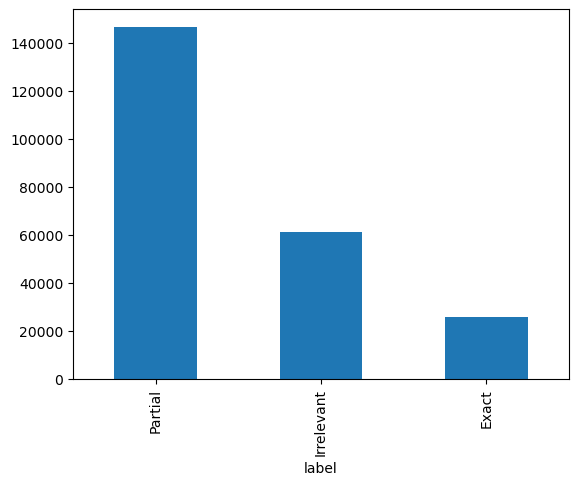

In [ ]:
# check the distribution of the labels 
label_df.label.value_counts().plot(kind='bar')

In [ ]:
# run evaluation 
#define functions for evaluating retrieval performance more fairly

def soft_map_at_k(true_ids, partial_ids, predicted_ids,  k=10, partial_score= 0.5):
    """
    Calculate the Mean Average Precision at K (MAP@K).

    Parameters:
    true_ids (list): List of relevant product IDs.
    predicted_ids (list): List of predicted product IDs.
    partial_ids (list): List of partially relevant product IDs.
    k (int): Number of top elements to consider.
             NOTE: IF you wish to change top k, please provide a justification for choosing the new value
    partial_score (float): Score for partially relevant items. preset at 0.5, but can be adjusted.

    Returns:
    float: soft-MAP@K score.
    """
    #if predicted_id is empty, or (both true_ids and partial_ids are empty), return 0
    if not predicted_ids or (not true_ids and not partial_ids):
        return 0.0

    score = 0.0
    num_hits = 0.0
   
    seen = set()
    for i, p_id in enumerate(predicted_ids[:k]):
        if p_id in seen:
             continue 
        seen.add(p_id)
            
        if p_id in true_ids :
            rel = 1.0 
        elif p_id in partial_ids:
            rel = partial_score 
        else:
            rel = 0.0

        if rel > 0:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
        
    normalizer = min(len(true_ids) + partial_score * len(partial_ids), k)
    return score / normalizer if normalizer > 0 else 0.0


def get_match_sets(query_id, label_df):
    group = label_df[label_df['query_id'] == query_id]
    exact = set(group[group['label'] == 'Exact']['product_id'].values)
    partial = set(group[group['label'] == 'Partial']['product_id'].values)
    return exact, partial

query_df['relevant_sets_with_partial'] = query_df['query_id'].apply(
    lambda qid: get_match_sets(qid, label_df)
)

query_df['soft_map@k'] = query_df.apply(
    lambda x: soft_map_at_k(
        x['relevant_sets_with_partial'][0], # exact  
        x['relevant_sets_with_partial'][1], # partial
        x['top_product_ids'],
        k=10
    ),
    axis=1
)
print("Soft MAP@10:", query_df['soft_map@k'].mean())

Soft MAP@10: 0.7510309277913445
